In [51]:
# Import libraries
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import linregress
from numba import njit
from tqdm.notebook import tqdm

# Part 1: 1d Ising model

In this part, we'll use the MCMC algorithm to compute various expectation values for the 1d Ising model

$\beta H = \sum_i J s_i s_{i+1} + B s_i.$

You will need to complete some code snippets below.

In [52]:
# 1d Ising model MCMC algorithm

# The main computation will be done in a function Ising1dMCMC, which has the following arguments:

# L = Linear size of system
# J = inverse temperature
# B = inverse temperature * magnetic field
# steps = number of steps in MC algorithm
# burn_time = number of steps before which we start collecting data from a sample
# num_points: We measure the correlation function <s_i s_{i+r}>. num_points defines the number of choices of r

# @njit
def Ising1dMCMC(L, J, B, steps, burn_time, num_points):

  s = np.random.randint(2, size = L).astype(float) * 2 - 1
  # Construct a random spin state (an array of size L containing random integers -1 or 1 with equal probability)

  Avg_magnetization = 0.0 # stores the average magnetization
  TwoPointCorrelations = np.zeros(num_points) # array of size num_points; will store 2-point correlation function

  r_initial = 5 # Position 1 for 2-point CF
  # Define an array to set the values of Position 2 for the 2-point CF measurement
  
  r_final = np.arange(num_points) + r_initial

  # Here's the MCMC algorithm

  count = 0 # counter variable
  for i in tqdm(range(steps)):

    flip_x = np.random.randint(L); # Randomly pick a position at which to flip a spin
    s_new = s.copy(); # make a copy of the spin state (Important!)
    s_new[flip_x] = -1 * s[flip_x]; # flip the spin

    AR = np.exp(2 * (J * (s[(flip_x - 1) % L] + s[(flip_x + 1) % L]) + B) * s[flip_x])
    #  #### INSERT CODE SNIPPET 2 HERE
    # AR stores the relative probability of the flipped spin state and the original state.
    # (If the energy difference is dE, this probability is exp(\beta * dE))
    # Note: be careful about boundary conditions while defining your arrays! We are assuming periodic boundary conditions.

    u = np.random.rand()

    # #### INSERT CODE SNIPPET 2 HERE Write the update condition in terms of AR (calculated above) and the uniform random number u
    # Assuming the proposal distribution is symmetric
    if u < AR:
      s = s_new

    # If burn time is elapsed, use the state stored in 's' to compute avg magnetization and 2-point correlation functions

    if i >= burn_time:
      TwoPointCorrelations += s[r_initial] * s[r_final]
      Avg_magnetization += np.mean(s)
      count += 1

  # Return the avg magnetization, the array of 2-point CF values, and the final spin state
  return Avg_magnetization/(count), TwoPointCorrelations/(count), s

In [53]:
# Initialize parameters
L = 100
J = -1.
B = 1.
steps = 10**6
burn_time = 25000
num_points = 10

In [54]:
# Run the MCMC algorithm from above
Avg_magnetization, TwoPointCorrelations1d, svals = Ising1dMCMC(L, J, B, steps, burn_time, num_points)
xvals = np.arange(num_points)

  0%|          | 0/1000000 [00:00<?, ?it/s]

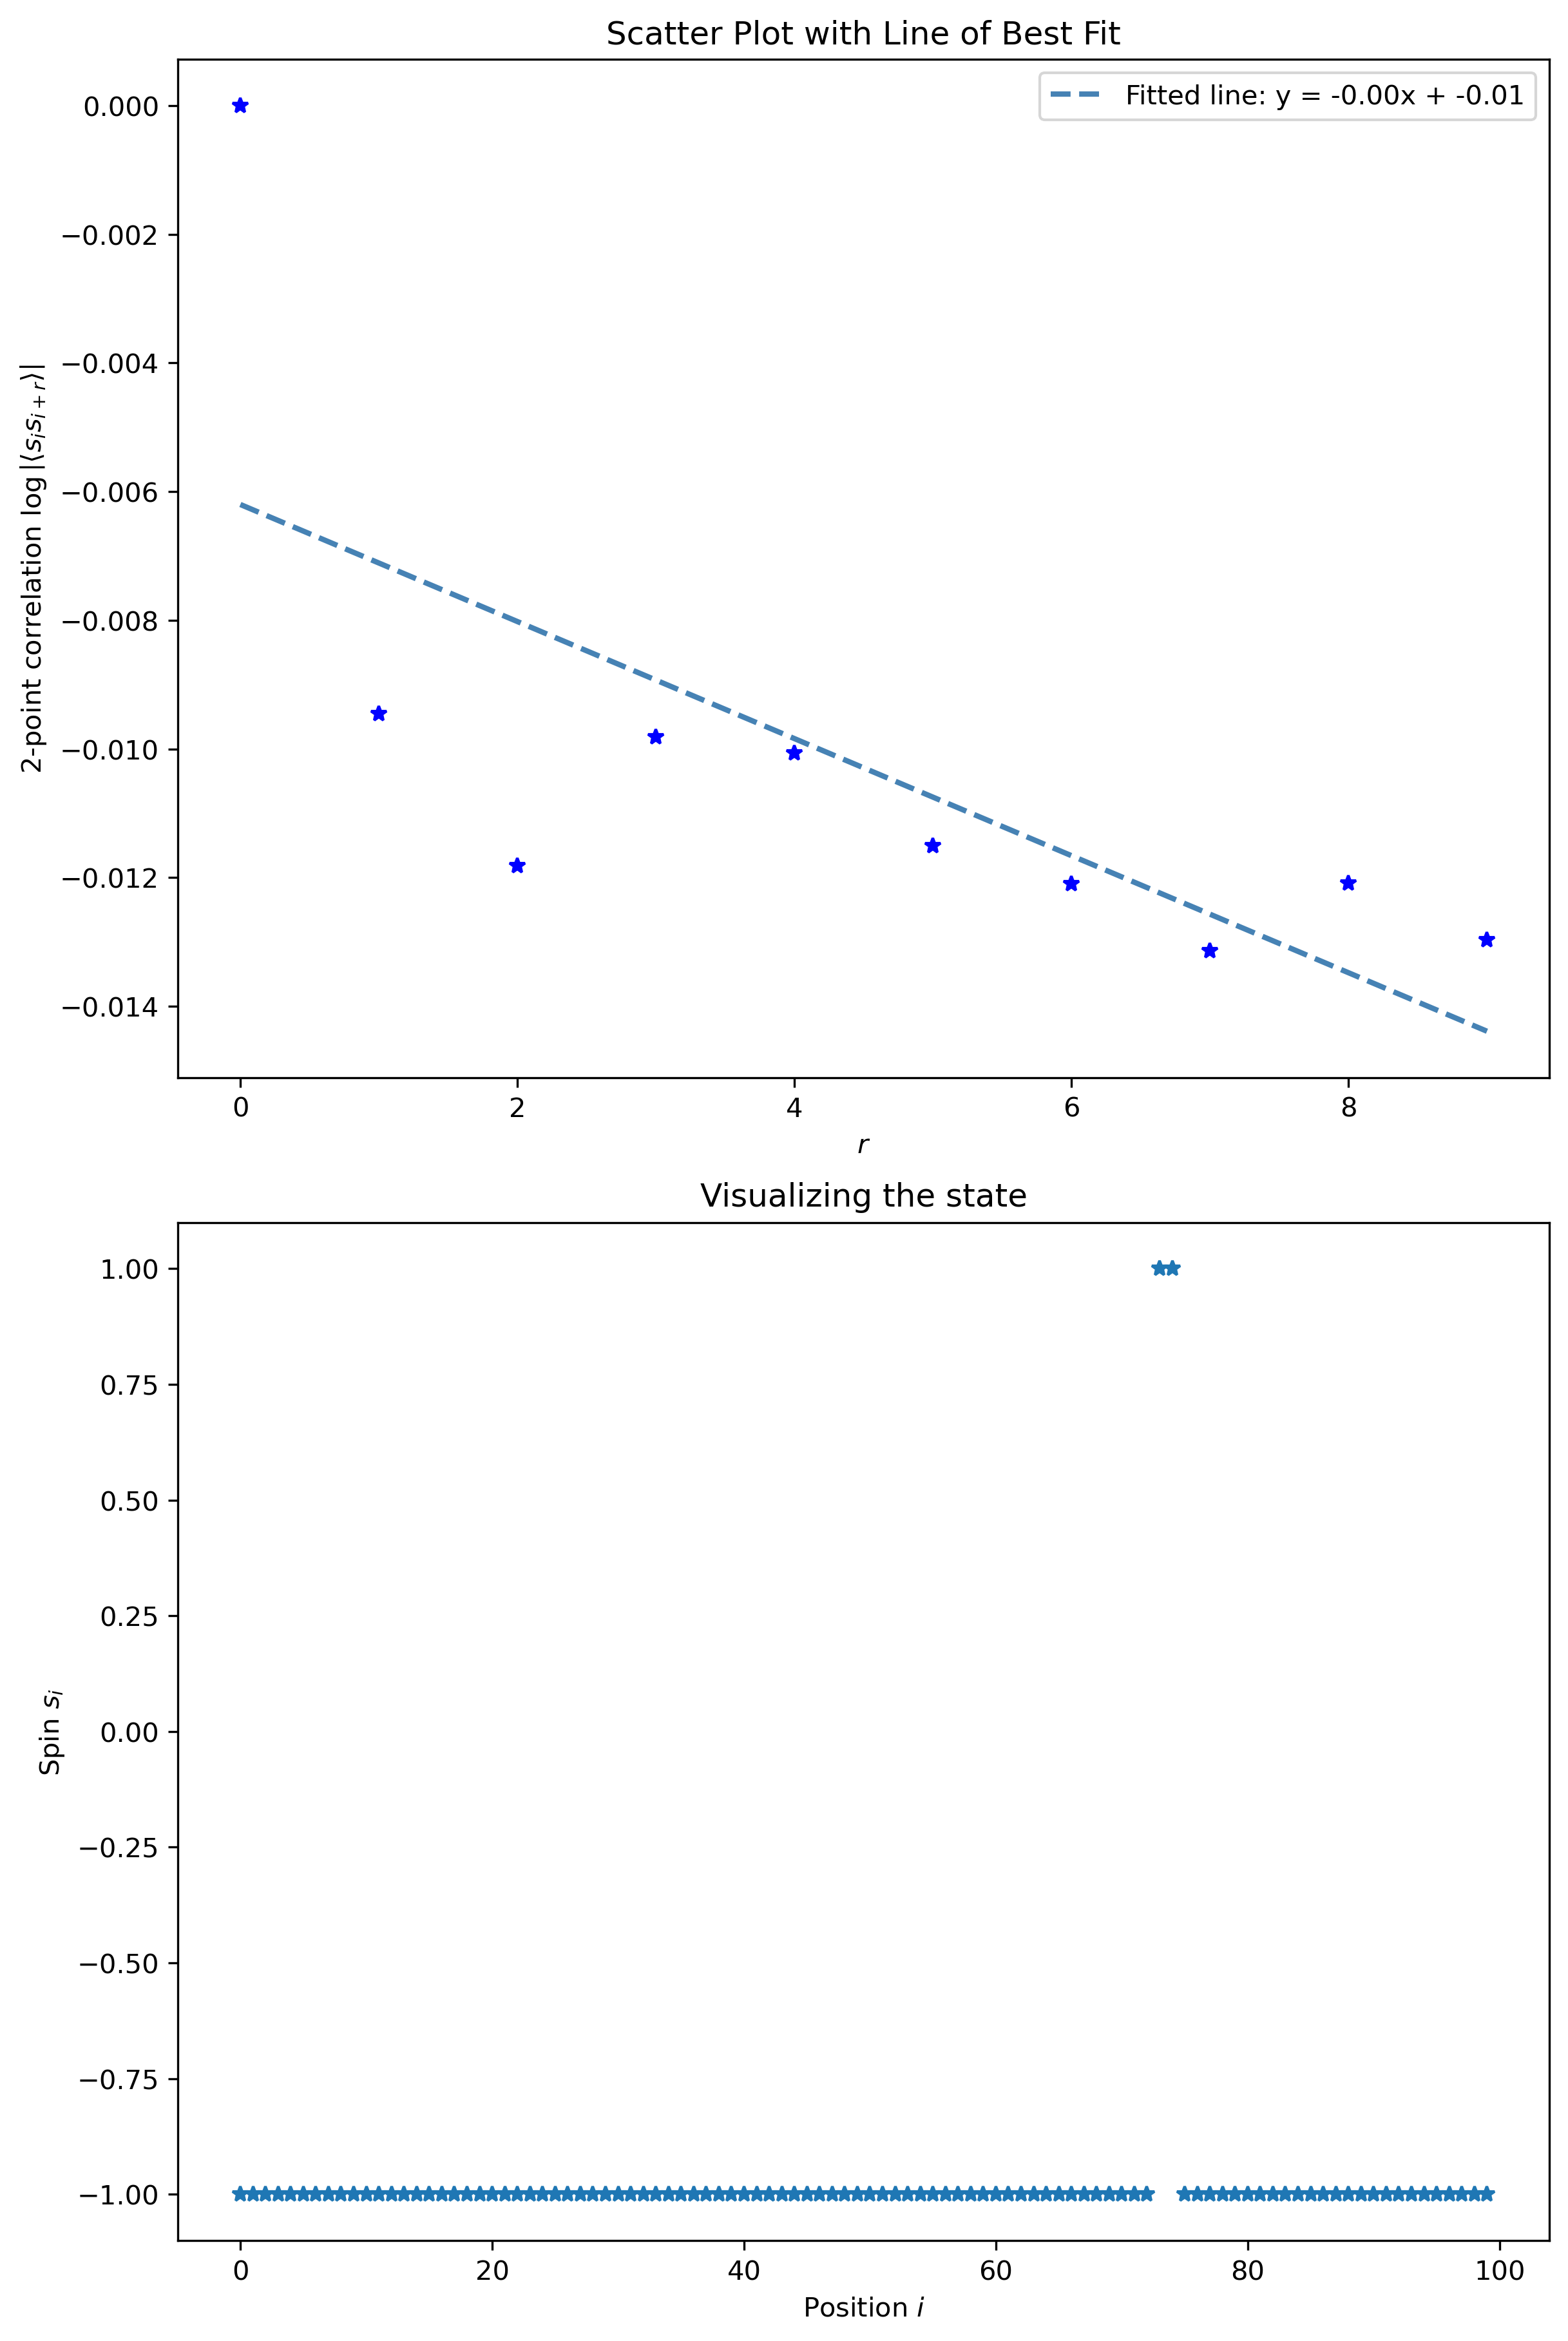

In [55]:
# Now plot the results. We'll make 2 plots:
# 1: Plot 2-point CF vs time
fig, ax = plt.subplots(2, 1, figsize = (8, 12), dpi = 300, layout = "constrained")
ax[0].plot(xvals, np.log(np.abs(TwoPointCorrelations1d)), 'b*')

# Calculate the line of best fit parameters (slope 'm', intercept 'b')
# The degree of the polynomial is set to 1 for a straight line
m, b = np.polyfit(xvals, np.log(np.abs(TwoPointCorrelations1d)), 1)

# 3. Create the y-values for the fitted line
# This can be done by calculating m*x + b for the x-values
y_fitted = m * xvals + b

# 4. Plot the original scatter points and the fitted line
ax[0].plot(xvals, y_fitted, color='steelblue', linestyle='--', linewidth=2, label=f'Fitted line: y = {m:.2f}x + {b:.2f}')

# Add labels, title, and a legend
ax[0].set_title("Scatter Plot with Line of Best Fit")
ax[0].set_xlabel("$r$")
ax[0].set_ylabel(r"2-point correlation $\log{\left|\langle s_is_{i+r}\rangle\right|}$")
ax[0].legend()

# 2: Plot the final spin state
ax[1].plot(svals,'*')
ax[1].set_title("Visualizing the state")
ax[1].set_xlabel("Position $i$")
ax[1].set_ylabel(r"Spin $s_i$")

plt.savefig("Ising_1D.png")

# Part 2: 2d Ising model

Same exercise, now in one higher dimension! Most of the code snippets you will need to complete are direct generalizations of the 1d case.

In [56]:
# 2d Ising model MCMC

# Initialize variables
def IsingMCMC2d(L, J, B, steps, burn_time, num_points):
# L = linear size (so now the spin state is an array of size L*L)
# steps = number of MC steps
# ri = (xi,yi) = position of initial point
# rj = (xj,yj) = position of final point
# NOTE: The 2 coordinates (x,y) are packaged into a single number as r = y + L*x
# so the points r = 1,2, ...,L form the left-most column in space
# and r = L+1, L+2, ..., 2L form the next column, and so on

# correlation is measured between ri and rj
# we use periodic boundary conditions


  s = np.random.randint(2, size = L * L).astype(float) * 2 - 1
  # Constructs a random spin state (an array of size L*L containing random integers 0 or 1 with equal probability)

  Avg_magnetization = 0.0 # stores the average magnetization
  TwoPointCorrelations2d = np.zeros(num_points)
  count = 0


  r_initial = 5
  r_final = np.arange(num_points) * L + r_initial

  for i in tqdm(range(steps)):
    # randomly pick a spin to flip
    flip_x = np.random.randint(L*L)
    # store a copy of the current spin state
    s_new = s.copy()
    # flip the chosen spin in the copy
    s_new[flip_x] = -1 * s[flip_x]
    # INSERT CODE SNIPPET 3 HERE
    # First calculate the numbers r1, r2, r3, r4 corresponding to the four nearest neighbors of flip_x
    # (careful about boundary conditions!)
    x = flip_x % L
    y = flip_x // L
    r1 = ((x - 1) % L) + L * y
    r2 = ((x + 1) % L) + L * y
    r3 = x + L * ((y - 1) % L)
    r4 = x + L * ((y + 1) % L)

    # INSERT CODE SNIPPET 4 HERE:
    # Calculate the acceptance ratio in terms of s[r1], s[r2], s[r3], s[r4] and s[flip_x]

    AR = np.exp(2 * (J * (s[r1] + s[r2] + s[r3] + s[r4]) + B) * s[flip_x])
    u = np.random.rand()

    # INSERT CODE SNIPPET 5 HERE
    # Write the update condition for s in terms of AR and u
    if u < AR:
      s = s_new

    # Now calculate the expectation values

    if i >= burn_time:
      TwoPointCorrelations2d += s[r_initial] * s[r_final]
      Avg_magnetization += np.mean(s)
      count += 1

  return Avg_magnetization/(count), TwoPointCorrelations2d/(count), s

In [59]:
# Initialize 2d Ising parameters
L = 100
J = -np.log(1 + np.sqrt(2)) / 2
B = 0
steps = 10**6
burn_time = 25000
num_points = 10

# Run the above MCMC
Avg_magnetization, TwoPointCorrelations2d, svals = IsingMCMC2d(L, J, B, steps, burn_time, num_points)
print(Avg_magnetization)
print(TwoPointCorrelations2d)
xvals = np.arange(num_points)

  0%|          | 0/1000000 [00:00<?, ?it/s]

0.024450118769237267
[1.         0.31733744 0.30823385 0.27227897 0.37965744 0.32670359
 0.40187077 0.37478564 0.30417846 0.46470564]


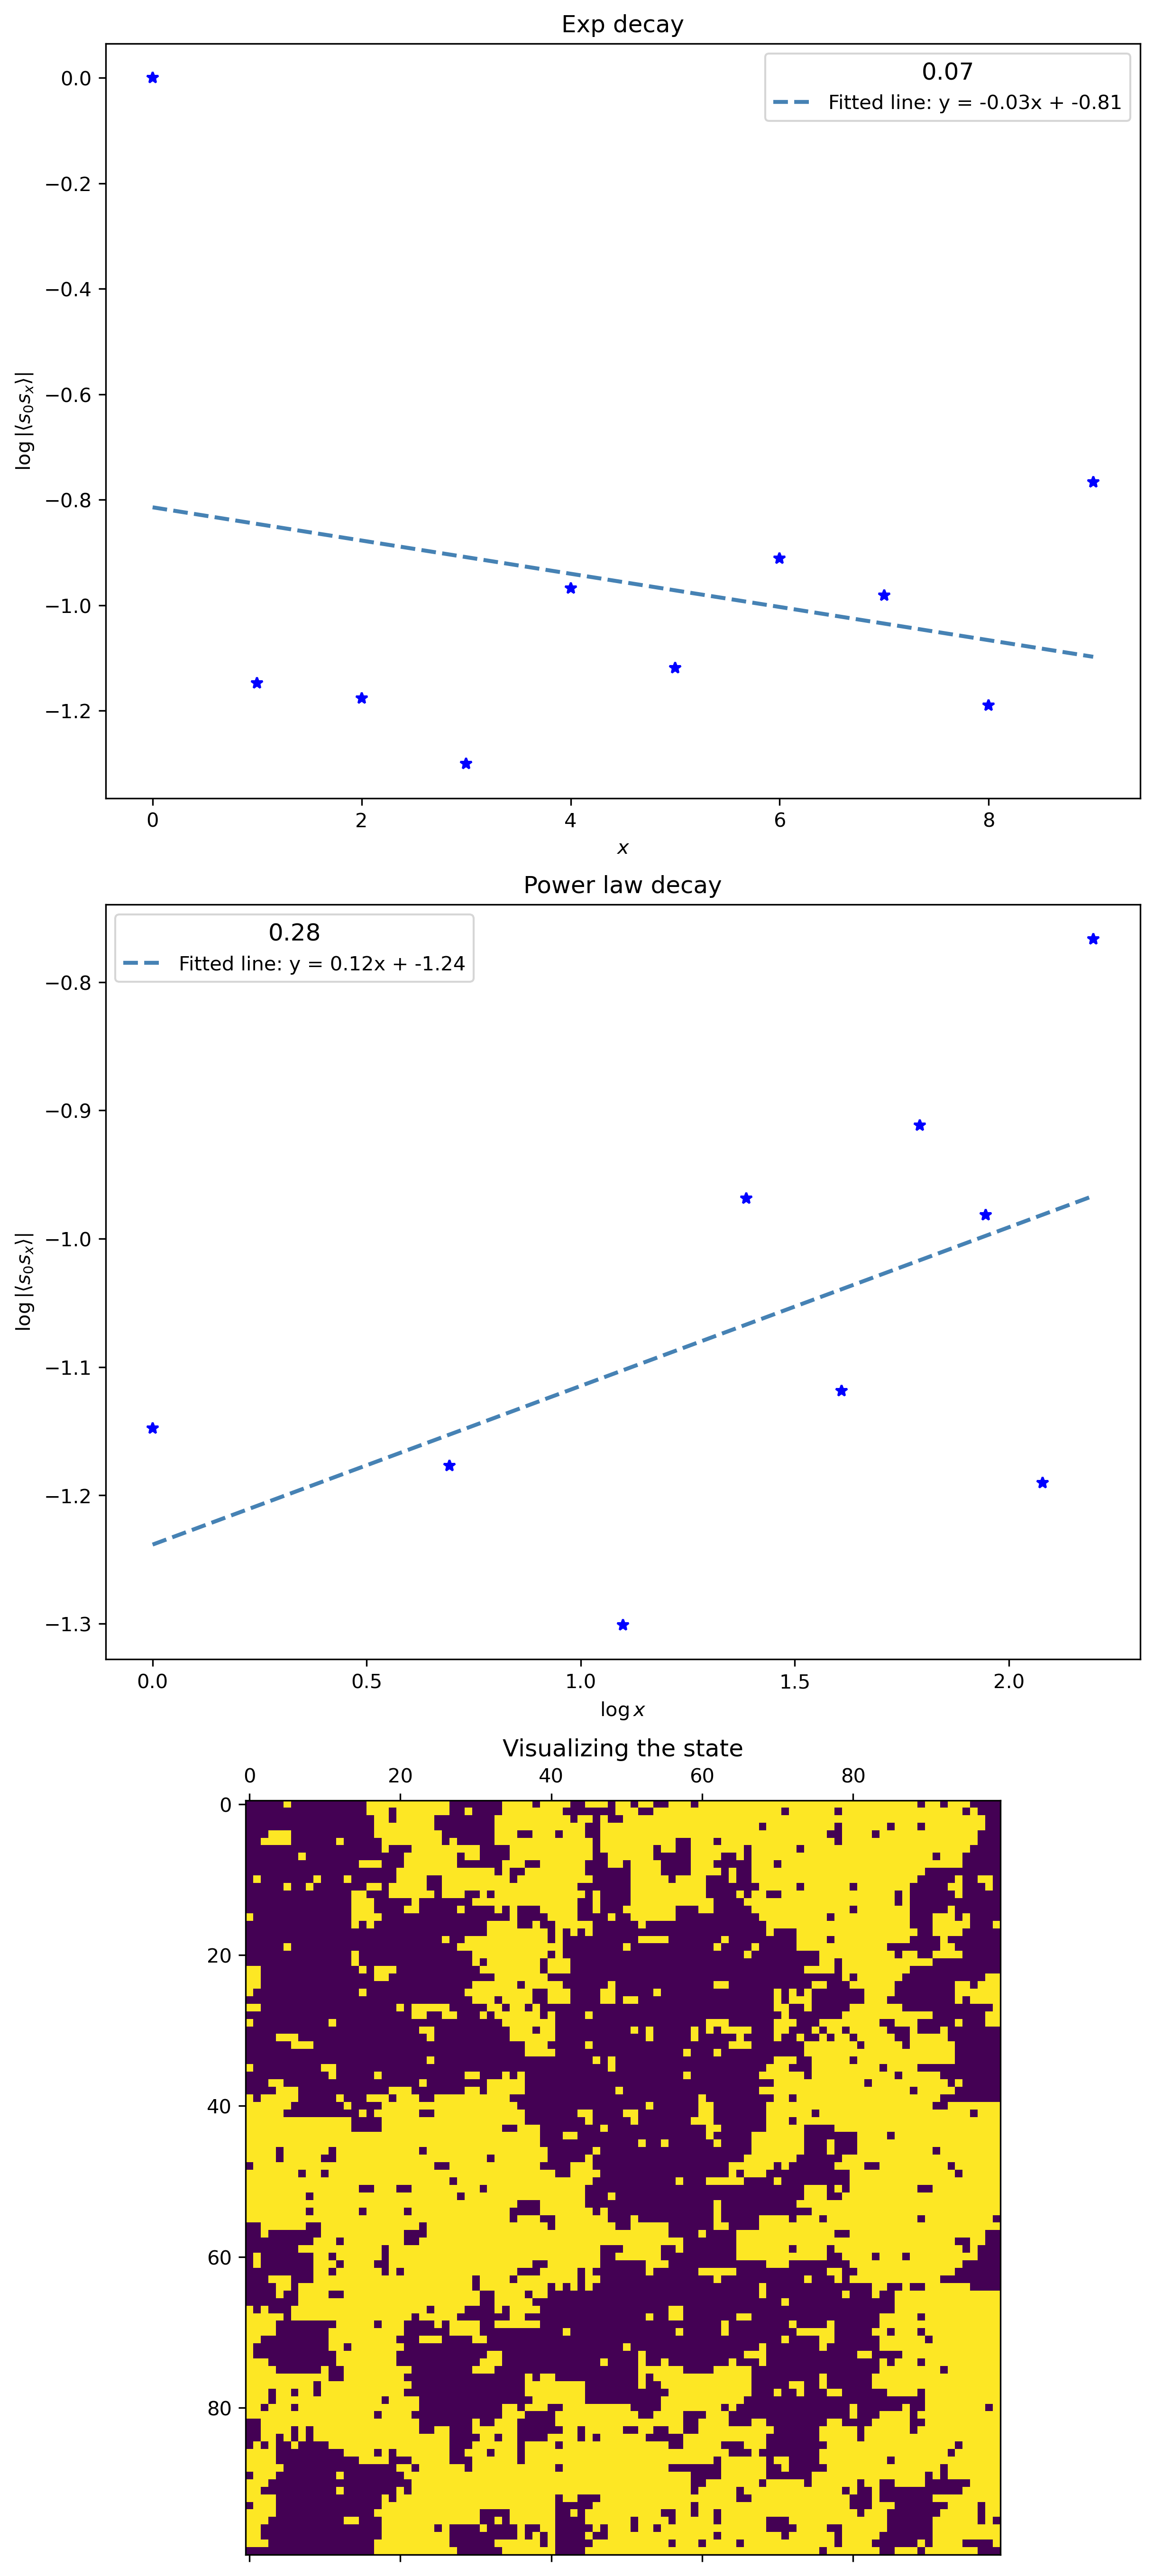

In [61]:
# PLOTTING!! We'll make 3 plots in total:
# 1. Check for exponential decay of 2-point CF
# 2. Check for power-law decay of 2-point CF
# 3. Visualize the final spin state

fig, ax = plt.subplots(3, 1, figsize = (8, 18), dpi = 300, layout = "constrained")

# 1. Test for exponential decay in correlation function
ax[0].plot(xvals, np.log(np.abs(TwoPointCorrelations2d)),'b*')
# Calculate the line of best fit parameters (slope 'm1', intercept 'b1')
# Note: the fitting tool is different from the 1d case
m1, b1, r1, p1, err1 = linregress(xvals, np.log(np.abs(TwoPointCorrelations2d)))

# Create the y-values for the fitted line
# This can be done by calculating m*x + b for the x-values
y_fitted1 = m1 * xvals + b1

# Plot the original scatter points and the fitted line

ax[0].plot(xvals, y_fitted1, color='steelblue', linestyle='--', linewidth=2, label=f'Fitted line: y = {m1:.2f}x + {b1:.2f}')

# Add labels, title, and a legend
ax[0].set_title("Exp decay")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel(r"$\log{\left|\langle s_0 s_x \rangle\right|}$")
ax[0].legend(title=np.around(r1**2,2), title_fontsize='12')

# 2. Test for power law decay
ax[1].plot(np.log(xvals[1:]), np.log(np.abs(TwoPointCorrelations2d[1:])),'b*')

# Calculate the line of best fit parameters (slope 'm2', intercept 'b2')
m2, b2, r2, p2, err2 = linregress(np.log(xvals[1:]), np.log(np.abs(TwoPointCorrelations2d[1:])))

# Create the y-values for the fitted line
# This can be done by calculating m*x + b for the x-values
y_fitted2 = m2 * np.log(xvals[1:]) + b2

# Plot the original scatter points and the fitted line

ax[1].plot(np.log(xvals[1:]), y_fitted2, color='steelblue', linestyle='--', linewidth=2, label=f'Fitted line: y = {m2:.2f}x + {b2:.2f}')

# Add labels, title, and a legend
ax[1].set_title("Power law decay")
ax[1].set_xlabel(r"$\log{x}$")
ax[1].set_ylabel(r"$\log{\left|\langle s_0 s_x \rangle\right|}$")
ax[1].legend(title=np.around(r2**2,2), title_fontsize='12')

# 3. Visualize the final spin state
ax[2].matshow(svals.reshape(L,L)); # NOTE: reshaping arrays can be very useful!
ax[2].set_title("Visualizing the state")

plt.savefig("Ising_2D.png")